<a href="https://colab.research.google.com/github/louisbetrisey/2026_Intro_Python/blob/main/1.3-numpy-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.3-numpy-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [2]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"gsw": "gsw", "pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import numpy as `np`, and encode units in your variable names.

## Exercise 1: Create and inspect

Build the following 3×4 field of temperatures (°C) as a numpy array:

`5.2 4.8 6.1 3.9 1.3 0.5 -0.8 -1.2 -2.6 -3.1 -1.9 0.2`

Print its `shape`, `ndim`, and `dtype`, and its overall mean rounded to two decimals.
Then create, and print, three arrays of the same shape without typing the shape out by hand:
all ones, a uniform reference field of 15.0 °C, and random values in [0, 1).

In [3]:
import numpy as np
temp_field = np.array([[5.2, 4.8, 6.1, 3.9], [1.3, 0.5, 0.8, -1.2], [-2.6, -3.1, -1.9, 0.2]])
print(temp_field.shape)
print(temp_field.ndim)
print(temp_field.dtype)

(3, 4)
2
float64


In [4]:
ones_field = np.ones(temp_field.shape)
reference_field = np.full(temp_field.shape, 15.0)
random_field = np.random.random(temp_field.shape)

print(ones_field)
print(reference_field)
print(random_field)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
[[15. 15. 15. 15.]
 [15. 15. 15. 15.]
 [15. 15. 15. 15.]]
[[0.66561893 0.16307035 0.02947905 0.4945719 ]
 [0.1924875  0.67113228 0.6092547  0.76754767]
 [0.88313028 0.14744484 0.50087135 0.55695941]]


## Exercise 2: Index and slice

Given

```python
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])
```

print the last row, the first column, and the 2×2 sub-block formed by the first two rows and the last two columns.

Finally, take a slice of the first row, change its first element to `99.0`, and print the original array. Then repeat using `.copy()`. Explain the difference in a comment.

In [5]:
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])
print(a[-1])
print(a[:,0])
print(a[0:2,2:4])

[ 9. 10. 11. 12.]
[1. 5. 9.]
[[3. 4.]
 [7. 8.]]


In [6]:
#Part 2
row = a[0, :]
row[0] = 99.0
print(a)

a[0, 0] = 1.0          # on remet la valeur d'origine pour le second test

# Avec .copy()
row_copy = a[0, :].copy()
row_copy[0] = 99.0
print(a)               # a n'a pas changé

[[99.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]


## Exercise 3: Masking and np.where

Given

```python
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])
```

print the values that exceed 10 °C, their mean, and the percentage of the field they make up.
Then build a clipped field in which every value below 0 °C is set to 0, using `np.where`.

In [7]:
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])

warm = temp_celsius > 10                      # le masque, rangé dans une variable

print(temp_celsius[warm])                     # les valeurs > 10
print(temp_celsius[warm].mean())              # leur moyenne
print(warm.sum() / temp_celsius.size * 100)   # leur pourcentage

clipped = np.where(temp_celsius < 0, 0, temp_celsius)
print(clipped)

[12. 15. 11.]
12.666666666666666
33.33333333333333
[[ 0.  12.   3. ]
 [ 8.   0.  15. ]
 [ 4.   0.5 11. ]]


## Exercise 4: Broadcasting and grids

Given the field below, add a per-column offset (length 4) to every row, and separately add a per-row offset (length 3) to every column.

```python
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])
```

Then build a grid of 4 evenly spaced longitudes from 6 to 9 °E and 3 evenly spaced latitudes
from 46 to 47 °N, so that it has the same shape as `field`. On that grid, compute a synthetic temperature
field that is 15.0 °C at (6 °E, 46 °N), cools by 0.6 °C per degree of latitude northward, and warms
by 0.2 °C per degree of longitude eastward. Compute it twice, once from the 2D arrays that
`np.meshgrid` returns and once by broadcasting the 1D latitudes and longitudes directly, and
confirm with `np.allclose` that the two agree.

In [8]:
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])


In [9]:
print(field + col_offset)             # ajoute [0,1,2,3] à chaque ligne
print(field + row_offset[:, None])    # ajoute 10, 20, 30 aux lignes 0, 1, 2

lon = np.linspace(6.0, 9.0, 4)        # 4 longitudes : [6. 7. 8. 9.]
lat = np.linspace(46.0, 47.0, 3)      # 3 latitudes : [46. 46.5 47.]

lon2d, lat2d = np.meshgrid(lon, lat)  # longitude et latitude de chaque case
temp_mesh = 15.0 - 0.6 * (lat2d - 46.0) + 0.2 * (lon2d - 6.0)
temp_broadcast = 15.0 - 0.6 * (lat[:, None] - 46.0) + 0.2 * (lon - 6.0)

print(temp_mesh)
print(np.allclose(temp_mesh, temp_broadcast))   # True

[[ 1.  3.  5.  7.]
 [ 5.  7.  9. 11.]
 [ 9. 11. 13. 15.]]
[[11. 12. 13. 14.]
 [25. 26. 27. 28.]
 [39. 40. 41. 42.]]
[[15.  15.2 15.4 15.6]
 [14.7 14.9 15.1 15.3]
 [14.4 14.6 14.8 15. ]]
True


## Exercise 5: Axis reductions

Given seasonal mean temperatures at three stations, one row per station and one column per season
(winter, spring, summer, autumn):

```python
seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])
```

print the annual mean at each station and the index of each station's warmest season. Then find the
coldest value in each season twice, once with the method and once with the numpy function, and
confirm they agree.

Finally, given four days of rainfall at two stations, one row per station,

```python
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])
```

use `cumsum` along the right axis to get the rain to date. Print the index of the station that was
wetter after the second day and the index of the station that was wetter after all four. Are they
the same station?

In [10]:
seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])

In [11]:
print(seasonal_celsius.mean(axis=1))      # moyenne annuelle de chaque station
print(seasonal_celsius.argmax(axis=1))    # indice de la saison la plus chaude

coldest_method = seasonal_celsius.min(axis=0)       # avec la méthode
coldest_function = np.min(seasonal_celsius, axis=0) # avec la fonction numpy
print(coldest_method)
print(np.allclose(coldest_method, coldest_function))

[10.125  7.65  12.1  ]
[2 2 2]
[-1.5  7.2 16.9  8. ]
True


In [12]:
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])

In [15]:
rain_to_date = rain_mm.cumsum(axis=1)     # cumul de pluie, jour après jour, axis = 1 on prend la somme par ligne et axis = 0 on prend la collone

print(rain_to_date[:, 1].argmax())        # station la plus arrosée après le jour 2
print(rain_to_date[:, -1].argmax())       # station la plus arrosée après les 4 jours

# Non, ce n'est pas la même station : la station 0 est en tête après 2 jours,
# mais la station 1 la dépasse après 4 jours.

[[ 0.   6.2  7.3  7.3]
 [ 2.4  2.4  2.4 10.7]]
0
1


## Exercise 6: Missing data and interpolation

Given hourly air temperatures with a gap of two readings,

```python
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])
```

fill the gap by linear interpolation against the integer index. Then print the NaN-aware mean of the
original series and the ordinary mean of the filled one. The two differ; say in a comment why.

In [17]:
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])
x = np.arange(temp_celsius.size)       # les positions : [0 1 2 3 4 5]
present = ~np.isnan(temp_celsius)      # True là où une valeur existe

linear_interpolation = np.interp(x, x[present], temp_celsius[present])
print(linear_interpolation)

print(np.nanmean(temp_celsius))        # moyenne de l'original, en ignorant les nan
print(linear_interpolation.mean())     # la différence vient des valeurs interpolées qui tirent la moyenne vers le haut

[12.  13.5 15.  16.5 18.  18.5]
15.5
15.583333333333334


In [19]:
print(x[present])

[0 1 4 5]


## Exercise 7: Avoid the dtype trap

An assistant wrote this function to compute each cell's share of the total rainfall in an integer
field of rain-gauge readings:

```python
def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
```

Call it and print the result. Explain in a comment why every share is 0, then fix the function
twice: once keeping the preallocation but passing `dtype=float` to `np.zeros_like`, and once
without preallocating at all. Confirm that each fixed version returns a float array whose shares
sum to 1.

In [31]:
def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
print(rain_mm)

[[0 2 5]
 [1 0 8]
 [3 4 2]]


In [24]:
def rain_share_fixed1(rain_mm):
    share = np.zeros_like(rain_mm, dtype=float)
    share[:] = rain_mm / rain_mm.sum()
    return share

In [25]:
def rain_share_fixed2(rain_mm):
    return rain_mm / rain_mm.sum()

In [26]:
result1 = rain_share_fixed1(rain_mm)
result2 = rain_share_fixed2(rain_mm)
print(result1)
print(result1.dtype, result1.sum())
print(result2.dtype, result2.sum())

[[0.   0.08 0.2 ]
 [0.04 0.   0.32]
 [0.12 0.16 0.08]]
float64 1.0000000000000002
float64 1.0000000000000002


## Exercise 8: Reshape and stack

1. Create the integers 0 to 11 as a 1D array, then reshape it into a 3×4 array and print both
   shapes.
2. Reshape the same data into a 4×3 array. Print it and say in a comment why the numbers appear
   in a different arrangement.
3. Use `reshape(-1)` to flatten your 3×4 array back to 1D, and confirm the shape.
4. Stack the 3×4 array on top of a row of zeros with `np.vstack`, and print the resulting shape.

In [35]:
int = np.arange(12)
print(int)
int_reshape = int.reshape(3,4)
print(int_reshape)
print(int_reshape.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
(3, 4)


In [36]:
int_reshape2 = int.reshape(4,3)
print(int_reshape2)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [38]:
int_reshape2 = int_reshape2.reshape(-1)
print(int_reshape2)

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [40]:
zeros_row = np.zeros(4)
stacked = np.vstack([int_reshape, zeros_row])
print(stacked.shape)

(4, 4)


## Exercise 9: Ocean float profiles

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/argo-float-cycle.png" alt="A diagram of one Argo float cycle, numbered one to seven, from deployment through drift, dive, ascent and satellite transmission" width="100%">

<em>One cycle of an Argo float: deployment, descent to a drifting depth of about 1000 m, ten days of
drift, a dive to the profiling depth, then the ascent during which the measurements are taken, and
transmission to satellite at the surface before the next cycle begins. The panel on the right shows
what one ascent produces — the temperature and salinity profiles you are about to work with.
Illustration &copy; Thomas Haessig, from
<a href="https://www.euro-argo.eu/Outreach/Educational-material/Discover-Argo-floats-for-kids/How-do-the-Argo-floats-fulfill-their-mission-in-the-Ocean">Euro-Argo ERIC's educational material</a>.</em>


[Argo](https://argo.ucsd.edu/) floats are autonomous instruments that drift with ocean currents,
periodically diving and surfacing while recording temperature, salinity, and pressure. Each dive
produces one *profile*: a set of measurements at many depth *levels*, with a single latitude,
longitude, and date attached.

This exercise uses real Argo data. Steps 1 to 8 use only what 1.1 to 1.3 cover: loading
arrays, inspecting shapes, rebuilding an axis, vectorised arithmetic, reductions along an axis,
boolean masks, and NaN-aware statistics. Steps 9 to 11 then plot what you computed.

**ℹ️ Beyond this subchapter**

Steps 9 to 11 use `matplotlib`, which gets its own treatment in 1.4. Import it once with
`import matplotlib.pyplot as plt`; after that you need only the functions below, and each is
named again where it is wanted:

- `plt.figure()` — start a new, empty figure; without it, every plot in a cell lands on the
  same axes
- [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) — a line, or
  one line per column when handed a 2D array
- [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) — a
  line with error bars
- [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) — points
- `plt.xlabel`, `plt.ylabel`, `plt.title` — each takes a string
- `plt.show()` — draw the current figure

An array of numbers with no picture attached is hard to sanity-check, which is why these three
steps sit here rather than waiting for 1.4: the profiles are the fastest way to see whether Steps 4
to 6 produced something physical.

In [41]:
# Pre-supplied: download and unzip the Argo data files.
import pooch

files = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/argo_float_data.zip",
    known_hash="sha256:dd913ba3450241bcd5d5697187ea68d398bdd7fd563a04cc74386834749c25f5",
    processor=pooch.Unzip(),
    path=pooch.os_cache("mlees"),
)
for f in sorted(files):
    print(f)

Unzipping contents of '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip' to '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip'


/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/P.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/S.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/T.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/date.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lat.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/levels.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lon.npy


**Step 1.** Load each `.npy` file into a numpy array with `np.load`. Name them `T` (temperature,
°C), `S` (practical salinity, unitless), `P` (pressure, dbar), `date`, `lat`, `lon`, and `level` (depth level).

Read the filenames printed above to work out which file is which.

In [42]:
from pathlib import Path
import numpy as np

folder = Path(files[0]).parent        # le dossier où se trouvent tous les fichiers

T = np.load(folder / "T.npy")         # température (°C)
S = np.load(folder / "S.npy")         # salinité
P = np.load(folder / "P.npy")         # pression (dbar)
date = np.load(folder / "date.npy")
lat = np.load(folder / "lat.npy")
lon = np.load(folder / "lon.npy")
level = np.load(folder / "levels.npy")

**Step 2.** Print the `shape` of every array you loaded. Then answer in a comment: which
dimension do `T`, `S`, and `P` share with `level`, and which do they share with `lat`, `lon`,
and `date`?

In [43]:
print("T:", T.shape)
print("S:", S.shape)
print("P:", P.shape)
print("date:", date.shape)
print("lat:", lat.shape)
print("lon:", lon.shape)
print("level:", level.shape)

# T, S et P ont la forme (78, 75).
# Leur premier axe (78 lignes) correspond à level : une ligne par niveau de profondeur.
# Leur second axe (75 colonnes) correspond à lat, lon et date : une colonne par profil.

T: (78, 75)
S: (78, 75)
P: (78, 75)
date: (75,)
lat: (75,)
lon: (75,)
level: (78,)


**Step 3.** The `level` array is a regular sequence. Recreate it twice — once with `np.arange`
and once with `np.linspace` — and confirm each matches the original using `np.allclose`.

Read `level[0]`, `level[-1]`, and `level.size` first to work out the arguments.

In [44]:
print(level[0], level[-1], level.size)    # 0 77 78

level_arange = np.arange(0, 78, 1)        # de 0 à 77, par pas de 1
level_linspace = np.linspace(0, 77, 78)   # 78 points, de 0 à 77

print(np.allclose(level_arange, level))   # True pour vérifier que ce sont bien les mêmes
print(np.allclose(level_linspace, level)) # True

0 77 78
True
True


**Step 4.** Compute the density of seawater relative to pure water, in kg m⁻³:

$$\rho - \rho_{\text{pure water}} = a\,S + b\,\Theta + c\,\Theta^{2}$$

where $S$ is salinity and $\Theta$ is the *conservative* temperature, computed from
temperature, salinity, and pressure by the `gsw` library. The constants are

```python
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3
```

The cell below imports the function. Compute `conservative_temp` and `relative_density`, print
the shape of your result, and check it matches `T`.

Both `CT_from_t` and the formula expect *absolute* salinity, in g/kg, while Argo reports
*practical* salinity, which has no unit. Absolute salinity is about 0.5 % larger; for these
profiles, using practical salinity in its place lowers every relative density by about
0.13 kg m⁻³, which is small enough to ignore here. `gsw.SA_from_SP` does the exact conversion
when it matters.

Source: Roquet et al. (2015), *J. Phys. Oceanogr.* 45, 2564–2579, and the
[TEOS-10 GSW toolbox](https://www.teos-10.org/).

In [46]:
# Pre-supplied: the conservative-temperature function from the gsw library
from gsw import CT_from_t

In [47]:
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3

conservative_temp = CT_from_t(S, T, P)
relative_density = a * S + b * conservative_temp + c * conservative_temp**2

print(relative_density.shape)
print(relative_density.shape == T.shape)

(78, 75)
True


**Step 5.** Compute the mean and the standard deviation of `T`, `S`, `P`, and
`relative_density` **at each depth**, averaging across all the profiles.

Check your result has the same shape as `level` — if it does not, you reduced along the wrong
axis.

In [52]:
T_mean = T.mean(axis=1)
T_std = T.std(axis=1)
S_mean = S.mean(axis=1)
S_std = S.std(axis=1)
P_mean = P.mean(axis=1)
P_std = P.std(axis=1)
density_mean = relative_density.mean(axis=1)
density_std = relative_density.std(axis=1)

print(T_mean.shape == level.shape)
print(T_mean)

True
[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan 10.80430666 10.49702667
 10.1749066   9.83453334  9.48625332  9.19793334  8.66010666  8.12324001
  7.60221333  7.15289333  6.74250667  6.39543999  6.04598667  5.74538665
  5.48913333  5.26604001  5.08768     4.93479998  4.77769334  4.65368
  4.54237334  4.44274664  4.35933333         nan         nan         nan
         nan         nan         nan         nan         nan         nan]


**Step 6.** Look at the mean you just computed. Many entries are `nan`, because Argo profiles
contain missing values and an ordinary mean propagates them.

1. Count how many values in `T` are missing, using `np.isnan` and a sum over the boolean mask.
2. Express that as a percentage of all values in `T`.
3. Recompute the mean and standard deviation with `np.nanmean` and `np.nanstd`, and confirm no
   `nan` remains.

In [53]:
# 1. Compter les valeurs manquantes dans T
n_missing = np.isnan(T).sum()
print(n_missing)

# 2. En pourcentage de toutes les valeurs de T
percent_missing = n_missing / T.size * 100
print(percent_missing)

# 3. Recalculer avec les versions qui ignorent les nan
T_mean = np.nanmean(T, axis=1)
T_std = np.nanstd(T, axis=1)
S_mean = np.nanmean(S, axis=1)
S_std = np.nanstd(S, axis=1)
P_mean = np.nanmean(P, axis=1)
P_std = np.nanstd(P, axis=1)
density_mean = np.nanmean(relative_density, axis=1)
density_std = np.nanstd(relative_density, axis=1)

# Confirmer qu'il ne reste aucun nan
print(np.isnan(T_mean).sum(), np.isnan(T_std).sum())


101
1.7264957264957266
0 0


**Step 7.** Using `np.where`, build an array that labels each depth `"warm"` where the mean
temperature there is above 10 °C and `"cold"` otherwise. Print the first ten labels alongside
the first ten depths.

Then, using a boolean mask, print the depths at which the mean temperature is below 5 °C.

In [54]:
# Étiqueter chaque profondeur : "warm" si la moyenne dépasse 10 °C, "cold" sinon
labels = np.where(T_mean > 10, "warm", "cold")

# Afficher les 10 premières étiquettes à côté des 10 premières profondeurs
for depth, label in zip(level[:10], labels[:10]):
    print(depth, label)

# Masque booléen : les profondeurs où la moyenne est sous 5 °C
cold_mask = T_mean < 5
print(level[cold_mask])

0 warm
1 warm
2 warm
3 warm
4 warm
5 warm
6 warm
7 warm
8 warm
9 warm
[63 64 65 66 67 68 69 70 71 72 73 74 75 76 77]


**Step 8.** Assemble a summary array with `np.vstack`: one row of depths, one of mean
temperature, one of mean salinity, and one of mean relative density — four rows in total.

Print its shape, save it to `_files/argo_summary.npy`, load it back, and confirm with `np.allclose`
that the round trip changed nothing.

In [55]:
from pathlib import Path

# Empiler les 4 lignes : profondeurs, température, salinité, densité
summary = np.vstack([level, T_mean, S_mean, density_mean])
print(summary.shape)

# Sauvegarder dans _files/argo_summary.npy
Path("_files").mkdir(exist_ok=True)
np.save("_files/argo_summary.npy", summary)

# Recharger et vérifier que rien n'a changé
reloaded = np.load("_files/argo_summary.npy")
print(np.allclose(summary, reloaded))

(4, 78)
True


**Step 9.** Plot each of `T`, `S`, `P` and `relative_density` against depth — four figures, one
per variable.

Each array is `(level, profile)`, so handing the whole array to `plt.plot` draws one line per
profile. Put the variable on the *x*-axis and `level` on the *y*-axis, which is the oceanographic
convention: depth runs down the page, and a profile is read the way the float measured it.

It will look messy, because 75 profiles are drawn on top of each other.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-profiles.png" alt="Many overlapping salinity profiles plotted against depth level, forming a dense band that shifts towards fresher water with depth" width="500">

<em>The salinity panel, as a check on yours. Label the axes and give each figure a title.</em>

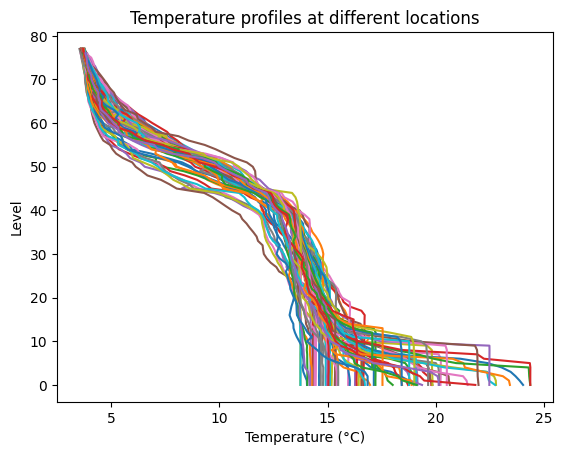

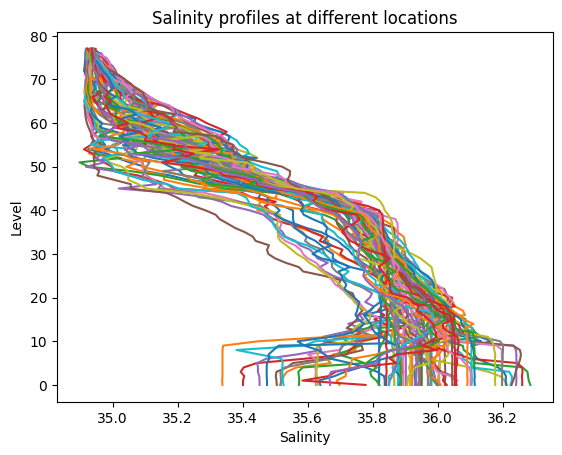

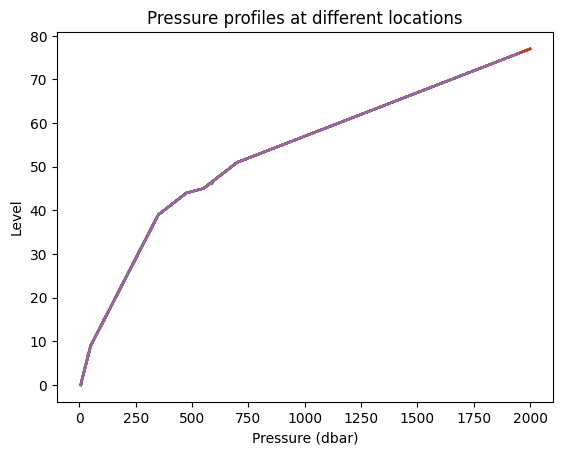

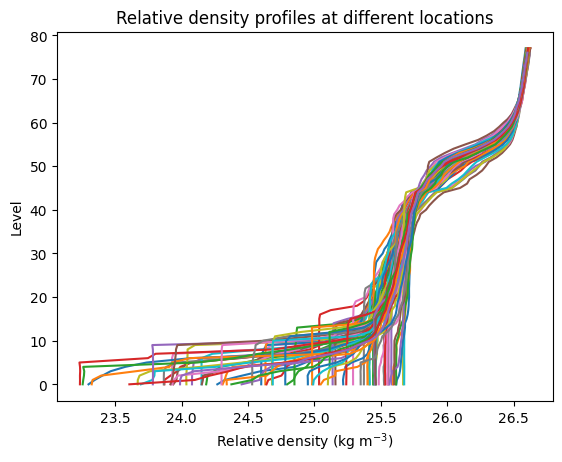

In [56]:
import matplotlib.pyplot as plt

# Température
plt.figure()
plt.plot(T, level)
plt.xlabel("Temperature (°C)")
plt.ylabel("Level")
plt.title("Temperature profiles at different locations")
plt.show()

# Salinité
plt.figure()
plt.plot(S, level)
plt.xlabel("Salinity")
plt.ylabel("Level")
plt.title("Salinity profiles at different locations")
plt.show()

# Pression
plt.figure()
plt.plot(P, level)
plt.xlabel("Pressure (dbar)")
plt.ylabel("Level")
plt.title("Pressure profiles at different locations")
plt.show()

# Densité relative
plt.figure()
plt.plot(relative_density, level)
plt.xlabel("Relative density (kg m$^{-3}$)")
plt.ylabel("Level")
plt.title("Relative density profiles at different locations")
plt.show()

**Step 10.** Now plot only the *mean* profile of each variable, with the standard deviation as
error bars.

Use the NaN-aware mean and standard deviation from Step 6, and draw them with `plt.errorbar`.
Because the variable is on the *x*-axis, the spread is a *horizontal* error bar — the keyword is
`xerr`, not `yerr`.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-mean-profiles.png" alt="A single mean salinity profile against depth level with horizontal error bars at each level" width="500">

<em>The salinity panel again, reduced from 75 profiles to one line and its spread.</em>


In a comment, say what the width of the error bars tells you about how much the profiles disagree
near the surface compared with at depth.

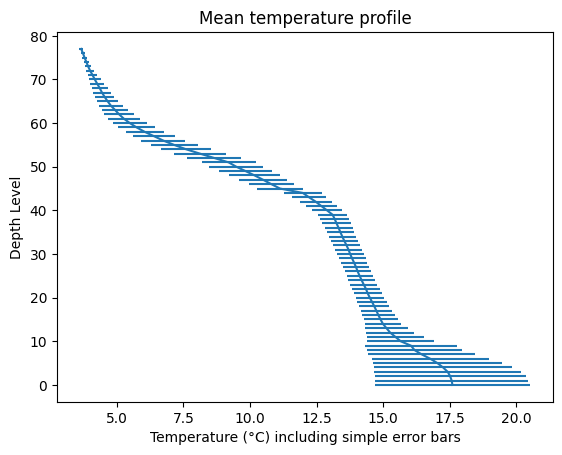

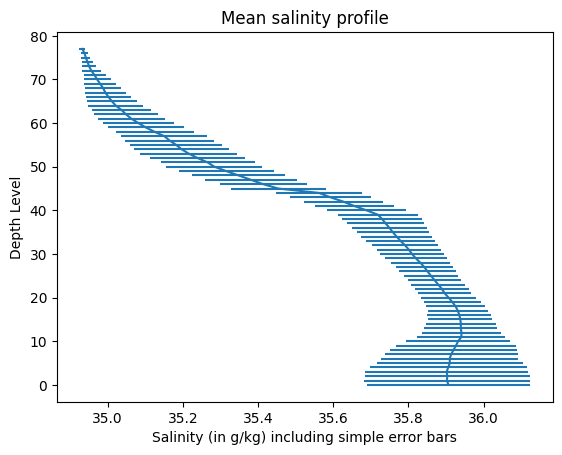

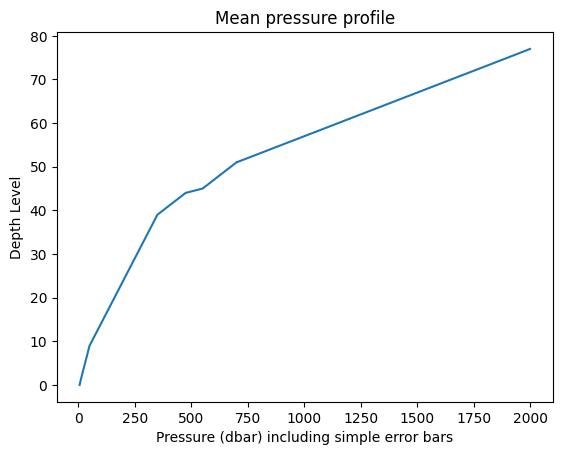

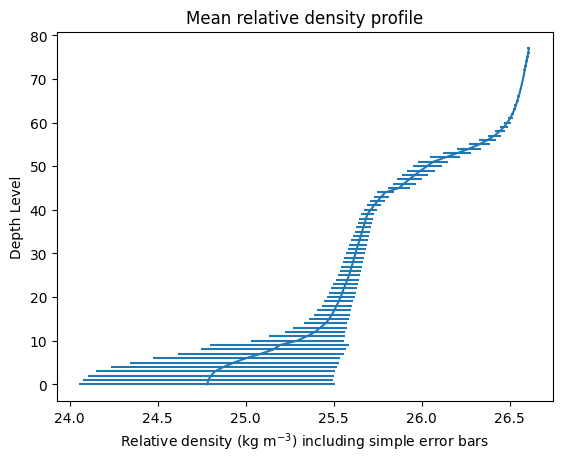

In [59]:
# Température
plt.figure()
plt.errorbar(T_mean, level, xerr=T_std)
plt.xlabel("Temperature (°C) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean temperature profile")
plt.show()

# Salinité
plt.figure()
plt.errorbar(S_mean, level, xerr=S_std)
plt.xlabel("Salinity (in g/kg) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean salinity profile")
plt.show()


# Pression
plt.figure()
plt.errorbar(P_mean, level, xerr=P_std)
plt.xlabel("Pressure (dbar) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean pressure profile")
plt.show()

# Densité relative
plt.figure()
plt.errorbar(density_mean, level, xerr=density_std)
plt.xlabel("Relative density (kg m$^{-3}$) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean relative density profile")
plt.show()


**Step 11.** Scatter the profiles' longitudes against their latitudes.

One point per profile. Label both axes and give it a title, and set the marker size with `s=` so
the points are readable. Then print the first three entries of `date` and the last one.

In a comment, say what the dates and the shape of the cloud tell you about how this set of
profiles was collected, and by how many floats.

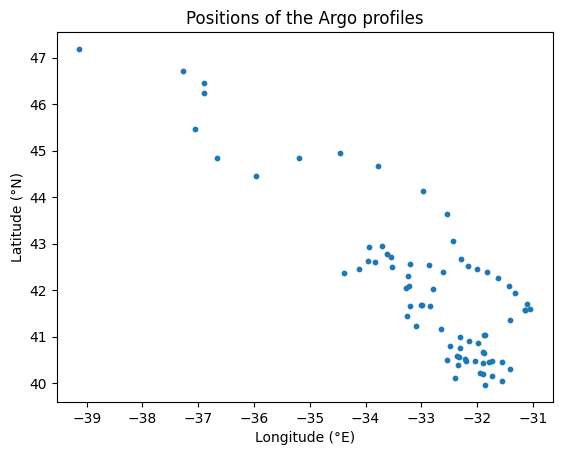

['2012-07-13T22:33:06.019200000' '2012-07-23T22:54:59.990400000'
 '2012-08-02T22:55:52.003200000']
2014-07-24T03:02:33.014400000


In [69]:
plt.figure()
plt.scatter(lon, lat, s=10)
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Positions of the Argo profiles")
plt.show()

print(date[:3])
print(date[-1])

# Les dates sont espacées d'environ 10 jours, de juillet 2012 à juillet 2014,
# et les points forment une trajectoire continue plutôt qu'un nuage dispersé.
# Ces 75 profils ont donc été mesurés par un seul flotteur, qui dérivait avec
# les courants et faisait une plongée tous les 10 jours pendant deux ans.

**ℹ️ What you just did**

You loaded a real oceanographic dataset, worked out its structure from the array shapes alone,
rebuilt a coordinate axis and verified it, evaluated a published equation of state as one
vectorised expression over 5,850 measurements (78 depth levels by 75 profiles), reduced along the
right axis, counted the missing values and switched to NaN-aware statistics, and saved a derived
product.

None of the computation needed a loop over the data. In the next subchapter `xarray` attaches the
names (depth, profile, latitude) to the axes you have been tracking by hand, and `matplotlib` gets
its full treatment, including the line, error-bar and scatter plots you drew here.